# YEaaaw wassup

In [2]:
#Imports and other relevant stuff
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.spatial import Delaunay
import scipy.interpolate as interpolate

In [3]:
#Importing the data into DataFrames
boredata= pd.read_csv("https://github.com/Matei-Stoica-Uni/Capstone-Case-Study---Australia/blob/main/Data/recharge-australia_data-bores.csv?raw=true")
griddata= pd.read_csv("https://github.com/Matei-Stoica-Uni/Capstone-Case-Study---Australia/blob/main/Data/recharge-australia_data-gridded.csv?raw=true")

In [4]:
boredata.info()

<class 'pandas.DataFrame'>
RangeIndex: 98568 entries, 0 to 98567
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Bore_ID                 98568 non-null  str    
 1   State                   98568 non-null  str    
 2   Longitude               98568 non-null  float64
 3   Latitude                98568 non-null  float64
 4   Elevation               98568 non-null  float64
 5   Distance_to_coast       98568 non-null  float64
 6   Rainfall                98568 non-null  float64
 7   Seasonal_rainfall_zone  98568 non-null  str    
 8   Runoff_coefficient      98568 non-null  float64
 9   PET                     98568 non-null  float64
 10  NDVI                    98568 non-null  float64
 11  Soil_class              98568 non-null  str    
 12  Clay_fraction           98568 non-null  float64
 13  Recharge_rate           98568 non-null  float64
dtypes: float64(10), str(4)
memory usage: 10.5 MB


In [5]:
griddata.info()

<class 'pandas.DataFrame'>
RangeIndex: 277090 entries, 0 to 277089
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Longitude               277090 non-null  float64
 1   Latitude                277090 non-null  float64
 2   Elevation               277090 non-null  float64
 3   Distance_to_coast       277090 non-null  float64
 4   Rainfall                277090 non-null  float64
 5   Seasonal_rainfall_zone  277090 non-null  str    
 6   PET                     277090 non-null  float64
 7   NDVI                    277090 non-null  float64
 8   Soil_class              277090 non-null  str    
 9   Clay_fraction           277090 non-null  float64
dtypes: float64(8), str(2)
memory usage: 21.1 MB


Some info about the datasets' variables:

Borehole data:
- Bore_ID: str, should be int, not very tidy, repeated/incomplete ID numbers, some even with letters in them. Not very relevant data for us here.
- State: str, has 7 unique values (Queensland, Tasmania, Victoria, Western Australia, South Australia, New South Wales, Northern Territory). Does not seem particularly relevant here.
- Longitude [°E]: float, min=113.6535995, max=153.583287 
- Latitude [°N]: float, min=-43.411719 ,max=-11.0654695
- Elevation [m]: float, min=-26.0 ,max=1434.0. (wrt Australian Height Datum)
  Lon, lat and elev are location data, relevant here.
- Distance_to_coast [km]: float min=1.000235932, max= 926.703683. Distance to coast could indicate how much moisture from the sea the ground is getting, maybe relevant here.
- Rainfall [mm/yr]: float, min=108.5781, max=4231.02524, very relevant here, probably very strongly correlated with groundwater recharge
- Seasonal_rainfall_zone: str, has 20 unique values, but is a combination of the seasonality (summer, winter, uniform, +dominant) and rainfall amount ( less than 250 to more than 1200 mm/yr). Unkown relevance, will have to process more as well to transform to numerical data for model.
- Runoff coefficient: float, min=0.00041, max=0.74112, the higher it is, the less permeable the surface is, the lower it is, the more permeable it is. Relevant here.
- PET (Potential EvapoTranspiration) [mm/yr]: float, min= 1113.36244, max=3068.18368. Relevant for sure, but how much ? Maybe combine with precipitation to get some other variable ?
- NDVI (Normalized Difference Vegetation Index): float, between -1 and +1, with +1 being very healthy and dense vegetation, and 0 being barren soil, negative values are used for non-land stuff

In [6]:
set_of_test_points_lon = np.array(boredata['Longitude'])
set_of_test_points_lat = np.array(boredata['Latitude'])
set_of_test_points_recharge_rate = np.array(boredata['Recharge_rate'])
set_of_test_points = np.c_[set_of_test_points_lon, set_of_test_points_lat]

set_of_test_points_gridded_lon = np.array(griddata['Longitude'])
set_of_test_points_gridded_lat = np.array(griddata['Latitude'])

/home/matei/miniconda3/envs/GeodataFundamentals-env/lib/python3.14/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


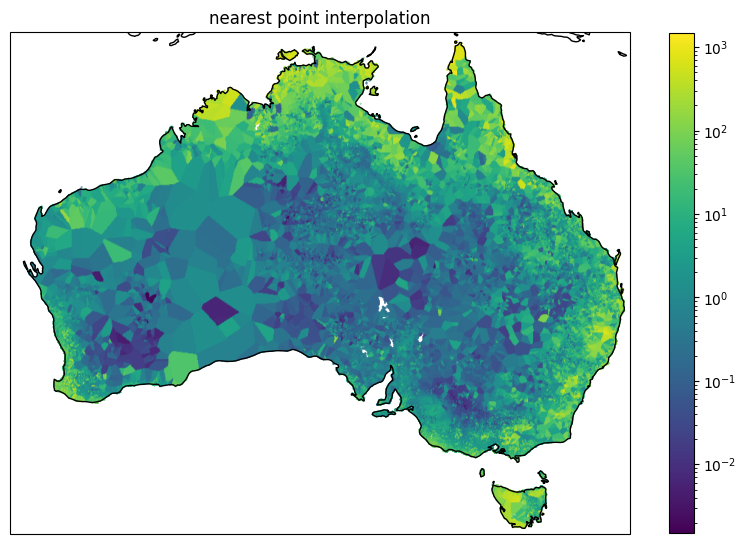

In [7]:
plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
#ax.add_feature(cfeature.LAND)
#ax.add_feature(cfeature.BORDERS)
#ax.add_feature(cfeature.COASTLINE)
ax.scatter(set_of_test_points_lon, set_of_test_points_lat,s=1, norm=colors.LogNorm(), c=set_of_test_points_recharge_rate, cmap='viridis')
interp_nearest = interpolate.NearestNDInterpolator(set_of_test_points, set_of_test_points_recharge_rate)
cax = ax.scatter(set_of_test_points_gridded_lon, set_of_test_points_gridded_lat, s=0.1, norm=colors.LogNorm(), c=interp_nearest(set_of_test_points_gridded_lon, set_of_test_points_gridded_lat), cmap='viridis')
ax.set_xlim(112,154)
ax.set_ylim(-44,-10)
plt.colorbar(cax, shrink=0.65)
plt.title('nearest point interpolation')
plt.show()

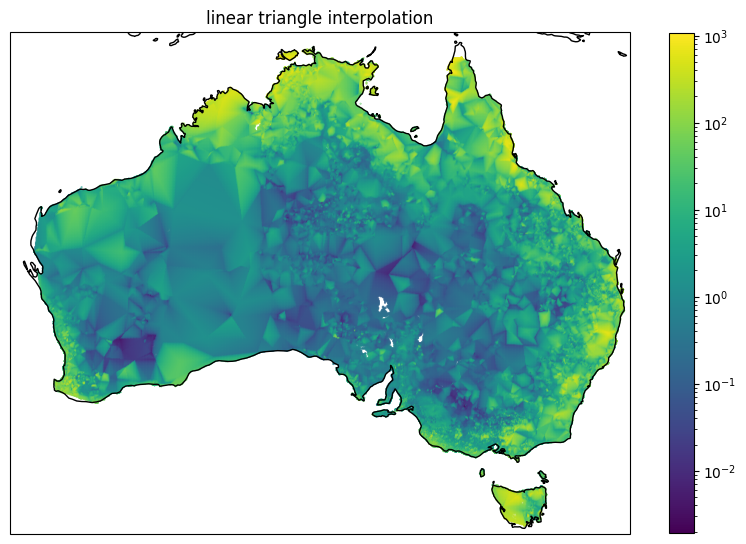

In [8]:
plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
#ax.add_feature(cfeature.LAND)
#ax.add_feature(cfeature.BORDERS)
#ax.add_feature(cfeature.COASTLINE)
ax.scatter(set_of_test_points_lon, set_of_test_points_lat,s=1, norm=colors.LogNorm(), c=set_of_test_points_recharge_rate, cmap='viridis')
interp = interpolate.LinearNDInterpolator(set_of_test_points, set_of_test_points_recharge_rate)
cax = ax.scatter(set_of_test_points_gridded_lon, set_of_test_points_gridded_lat, s=0.1, norm=colors.LogNorm(), c=interp(set_of_test_points_gridded_lon, set_of_test_points_gridded_lat), cmap='viridis')
ax.set_xlim(112,154)
ax.set_ylim(-44,-10)
plt.colorbar(cax, shrink=0.65)
plt.title('linear triangle interpolation')
plt.show()

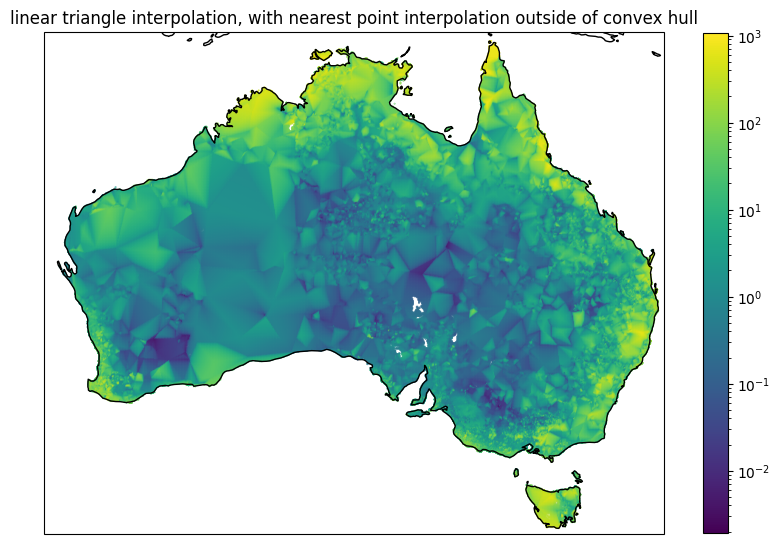

In [9]:
plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
#ax.add_feature(cfeature.LAND)
#ax.add_feature(cfeature.BORDERS)
#ax.add_feature(cfeature.COASTLINE)
ax.scatter(set_of_test_points_lon, set_of_test_points_lat,s=1, norm=colors.LogNorm(), c=set_of_test_points_recharge_rate, cmap='viridis')
interp = interpolate.LinearNDInterpolator(set_of_test_points, set_of_test_points_recharge_rate, fill_value=99999999)
interp_values = []
for i in range(len(set_of_test_points_gridded_lon)):
    if interp(set_of_test_points_gridded_lon[i], set_of_test_points_gridded_lat[i]) == 99999999:
        interp_values.append(interp_nearest(set_of_test_points_gridded_lon[i], set_of_test_points_gridded_lat[i]))
        #print(f'fill value at {i}')
    else:
        interp_values.append(interp(set_of_test_points_gridded_lon[i], set_of_test_points_gridded_lat[i]))
cax = ax.scatter(set_of_test_points_gridded_lon, set_of_test_points_gridded_lat, s=0.1, norm=colors.LogNorm(), c=interp_values, cmap='viridis')
ax.set_xlim(112,154)
ax.set_ylim(-44,-10)
plt.colorbar(cax, shrink=0.65)
plt.title('linear triangle interpolation, with nearest point interpolation outside of convex hull')
plt.show()

[[36611 95403 33458]
 [88560 75953 88564]
 [16970 17244 15718]
 ...
 [31679 31708 31681]
 [31665 31712 31662]
 [31662 31712 31658]]


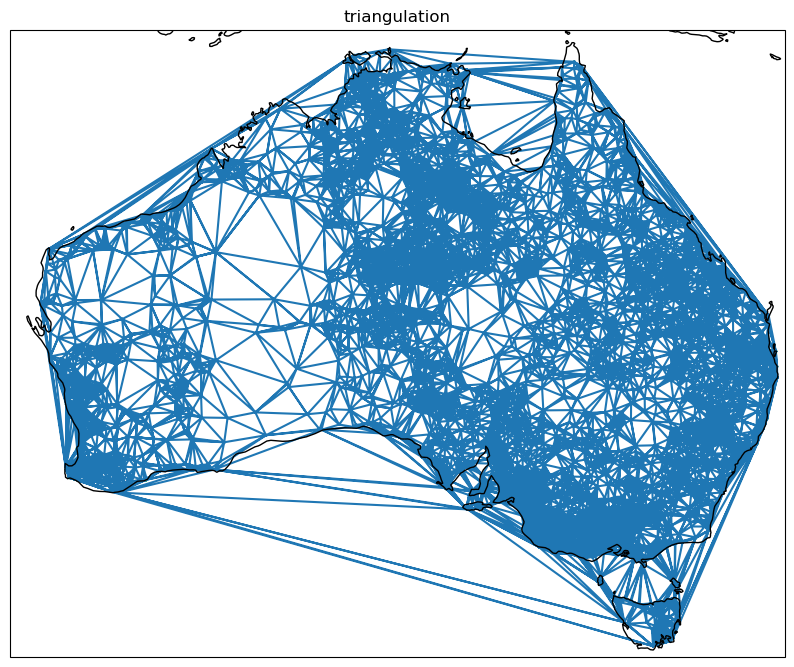

In [16]:
tri = Delaunay(set_of_test_points)
print(tri.simplices.copy())

plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
#ax.add_feature(cfeature.LAND)
#ax.add_feature(cfeature.BORDERS)
#ax.add_feature(cfeature.COASTLINE)
ax.scatter(set_of_test_points_lon, set_of_test_points_lat,s=1, norm=colors.LogNorm(), c=set_of_test_points_recharge_rate, cmap='viridis')
ax.triplot(set_of_test_points_lon,set_of_test_points_lat, tri.simplices.copy())
ax.set_xlim(112,154)
ax.set_ylim(-44,-10)
plt.title('triangulation')
plt.show()

array([[<Axes: xlabel='Longitude', ylabel='Longitude'>,
        <Axes: xlabel='Latitude', ylabel='Longitude'>,
        <Axes: xlabel='Elevation', ylabel='Longitude'>,
        <Axes: xlabel='Distance_to_coast', ylabel='Longitude'>,
        <Axes: xlabel='Rainfall', ylabel='Longitude'>,
        <Axes: xlabel='Runoff_coefficient', ylabel='Longitude'>,
        <Axes: xlabel='PET', ylabel='Longitude'>,
        <Axes: xlabel='NDVI', ylabel='Longitude'>,
        <Axes: xlabel='Clay_fraction', ylabel='Longitude'>,
        <Axes: xlabel='Recharge_rate', ylabel='Longitude'>],
       [<Axes: xlabel='Longitude', ylabel='Latitude'>,
        <Axes: xlabel='Latitude', ylabel='Latitude'>,
        <Axes: xlabel='Elevation', ylabel='Latitude'>,
        <Axes: xlabel='Distance_to_coast', ylabel='Latitude'>,
        <Axes: xlabel='Rainfall', ylabel='Latitude'>,
        <Axes: xlabel='Runoff_coefficient', ylabel='Latitude'>,
        <Axes: xlabel='PET', ylabel='Latitude'>,
        <Axes: xlabel='NDVI', yla

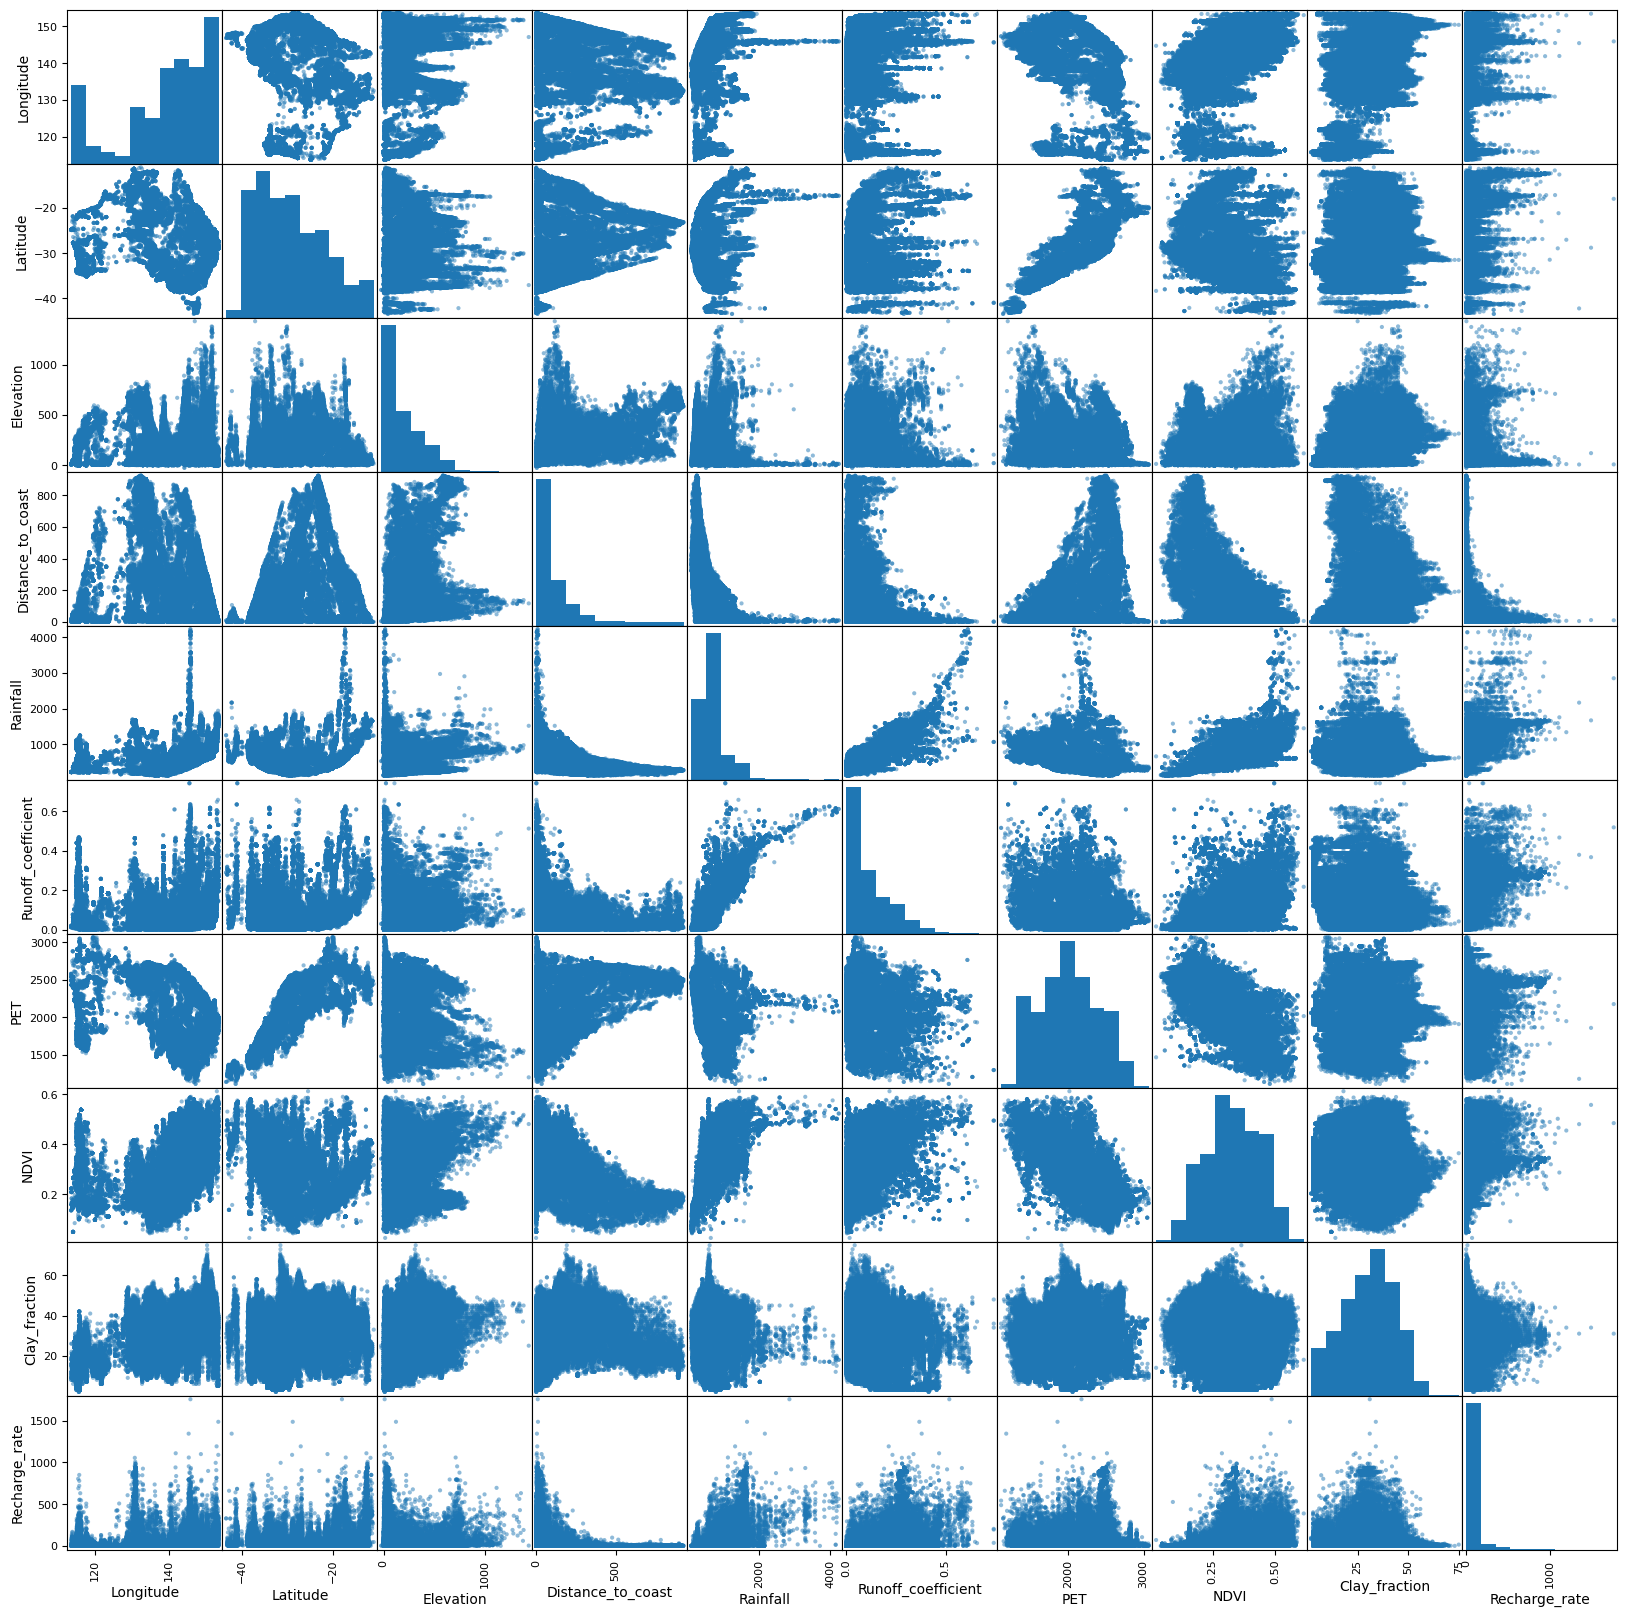

In [10]:
pd.plotting.scatter_matrix(boredata, figsize=(20,20))

In [17]:
boredata_nostr= boredata.drop(labels=['Bore_ID', 'Seasonal_rainfall_zone', 'State', 'Soil_class'], axis=1)
boredata_nostr.corr(method='pearson')

,Longitude,Latitude,Elevation,Distance_to_coast,Rainfall,Runoff_coefficient,PET,NDVI,Clay_fraction,Recharge_rate
Longitude,1.000000,-0.067339,0.181260,0.010499,0.147034,-0.131391,-0.275426,0.346792,0.707189,-0.081989
Latitude,-0.067339,1.000000,0.034565,0.204309,0.338926,0.284006,0.873718,-0.368410,0.135768,0.362821
Elevation,0.181260,0.034565,1.000000,0.520448,-0.253907,-0.260121,0.048579,-0.126690,0.315409,-0.146367
Distance_to_coast,0.010499,0.204309,0.520448,1.000000,-0.474349,-0.388185,0.426594,-0.524181,0.052669,-0.223828
Rainfall,0.147034,0.338926,-0.253907,-0.474349,1.000000,0.780634,-0.061958,0.562433,0.093830,0.620615
Runoff_coefficient,-0.131391,0.284006,-0.260121,-0.388185,0.780634,1.000000,0.021943,0.293213,-0.147173,0.469587
PET,-0.275426,0.873718,0.048579,0.426594,-0.061958,0.021943,1.000000,-0.687191,-0.029542,0.115113
NDVI,0.346792,-0.368410,-0.126690,-0.524181,0.562433,0.293213,-0.687191,1.000000,0.153541,0.189530
Clay_fraction,0.707189,0.135768,0.315409,0.052669,0.093830,-0.147173,-0.029542,0.153541,1.000000,-0.040403
Recharge_rate,-0.081989,0.362821,-0.146367,-0.223828,0.620615,0.469587,0.115113,0.189530,-0.040403,1.000000
